### IMPORT LIBRARY

In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

### LOAD DATASET

In [5]:
df = pd.read_csv("data/dataset_pretext.csv")

if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])

df.head()

,pretext,target_role,problem_category,current_level,blocker_type
0,apa dibutuhkan keterampilan untuk seniman vfx?...,vfx artist,direction_confused,intermediate,no_portfolio
1,Pengembang web di luar sana dapat Anda memberi...,entry level web developer,beginner_lost,zero,no_foundation
2,Tertarik dalam mengembangkan karir dalam kecer...,business intelligence analyst,direction_confused,intermediate,no_foundation
3,apa kemungkinan jalur karir untuk analis bisni...,business intelligence analyst,direction_confused,intermediate,no_portfolio
4,apa peluang terbaik untuk manajer analis denga...,business intelligence analyst,direction_confused,intermediate,no_portfolio


### DATA UNDERESTANDING

In [6]:
print("Shape:", df.shape)

df.info()

Shape: (2062, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2062 entries, 0 to 2061
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   pretext           2062 non-null   object
 1   target_role       2062 non-null   object
 2   problem_category  2062 non-null   object
 3   current_level     2062 non-null   object
 4   blocker_type      2062 non-null   object
dtypes: object(5)
memory usage: 80.7+ KB


In [7]:
df.describe(include="all")

,pretext,target_role,problem_category,current_level,blocker_type
count,2062,2062,2062,2062,2062
unique,2058,93,4,3,5
top,posisi analis tingkat masuk membantu? i am akt...,business intelligence analyst,direction_confused,intermediate,no_portfolio
freq,2,539,1746,1743,1056


In [8]:
df.isnull().sum()

pretext             0
target_role         0
problem_category    0
current_level       0
blocker_type        0
dtype: int64

### BUSINESS QUESTION 1
#### Karier apa yang paling banyak diminati pengguna?

### DATA PROCESSING

In [9]:
role_count = (
    df["target_role"]
    .value_counts()
    .reset_index()
)

role_count.columns = [
    "target_role",
    "total_users"
]

role_count.head(10)

,target_role,total_users
0,business intelligence analyst,539
1,it technician,144
2,application engineer,109
3,game developer,102
4,data science specialist,98
5,it engineer,95
6,software development engineer,83
7,entry level web developer,79
8,entry level programmer,73
9,multimedia architect,62


### VISUALIZATION

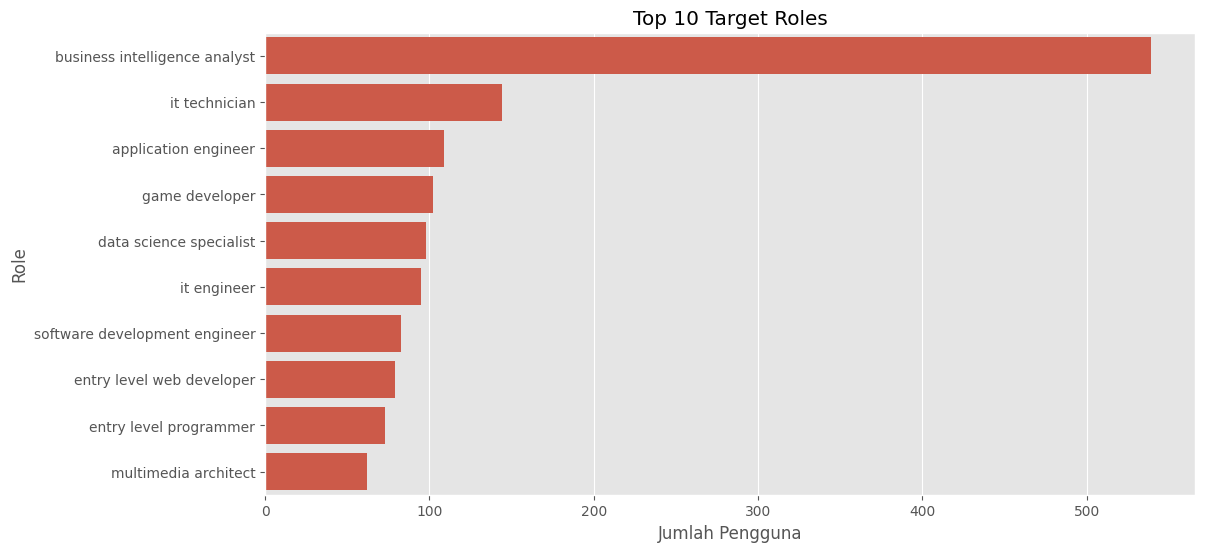

In [10]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=role_count.head(10),
    x="total_users",
    y="target_role"
)

plt.title("Top 10 Target Roles")
plt.xlabel("Jumlah Pengguna")
plt.ylabel("Role")

plt.show()

### INSIGHT

In [11]:
top_role = role_count.iloc[0]["target_role"]

print(
    f"Role yang paling diminati adalah {top_role}"
)

Role yang paling diminati adalah business intelligence analyst


### BUSINESS QUESTION 2
#### Apakah level pengguna memengaruhi jenis masalah yang dihadapi?

### DATA RPOCESSING

In [12]:
level_problem = pd.crosstab(
    df["current_level"],
    df["problem_category"]
)

level_problem

problem_category,beginner_lost,confidence_issue,direction_confused,overwhelmed
current_level,,,,
basic,9,0,114,19
intermediate,113,3,1555,72
zero,74,1,77,25


### VISUALIZATION

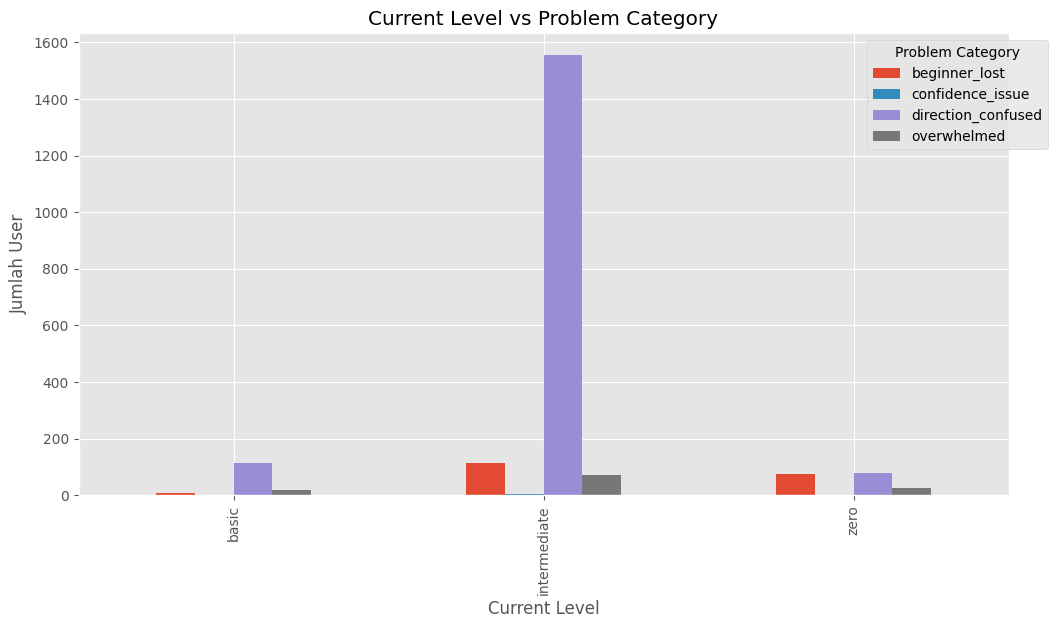

In [13]:
level_problem.plot(
    kind="bar",
    figsize=(12,6)
)

plt.title(
    "Current Level vs Problem Category"
)

plt.xlabel("Current Level")
plt.ylabel("Jumlah User")

plt.legend(
    title="Problem Category",
    bbox_to_anchor=(1.05, 1)
)

plt.show()

INSIGHT

In [14]:
level_problem.idxmax(axis=1)

current_level
basic           direction_confused
intermediate    direction_confused
zero            direction_confused
dtype: object

### DISTRIBUSI PROBLEM CATEGORY

In [15]:
problem_count = (
    df["problem_category"]
    .value_counts()
)

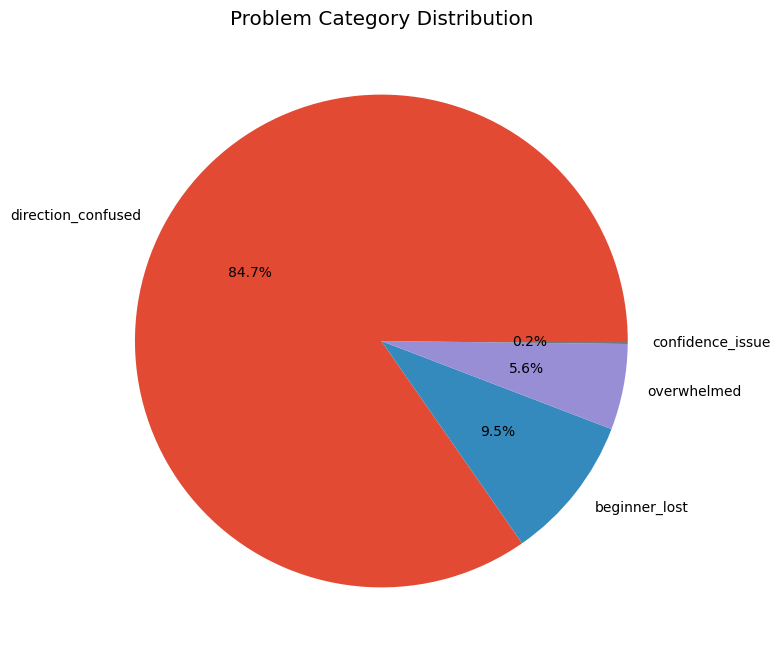

In [16]:
plt.figure(figsize=(8,8))

plt.pie(
    problem_count.values,
    labels=problem_count.index,
    autopct="%1.1f%%"
)

plt.title("Problem Category Distribution")

plt.show()

### DISTRIBUSI CURRENT LEVEL

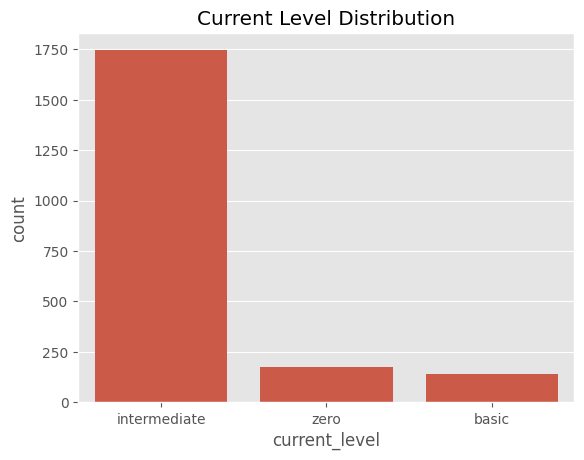

In [17]:
sns.countplot(
    data=df,
    x="current_level"
)

plt.title(
    "Current Level Distribution"
)

plt.show()

DISTRIBUSI BLOCKER TYPE

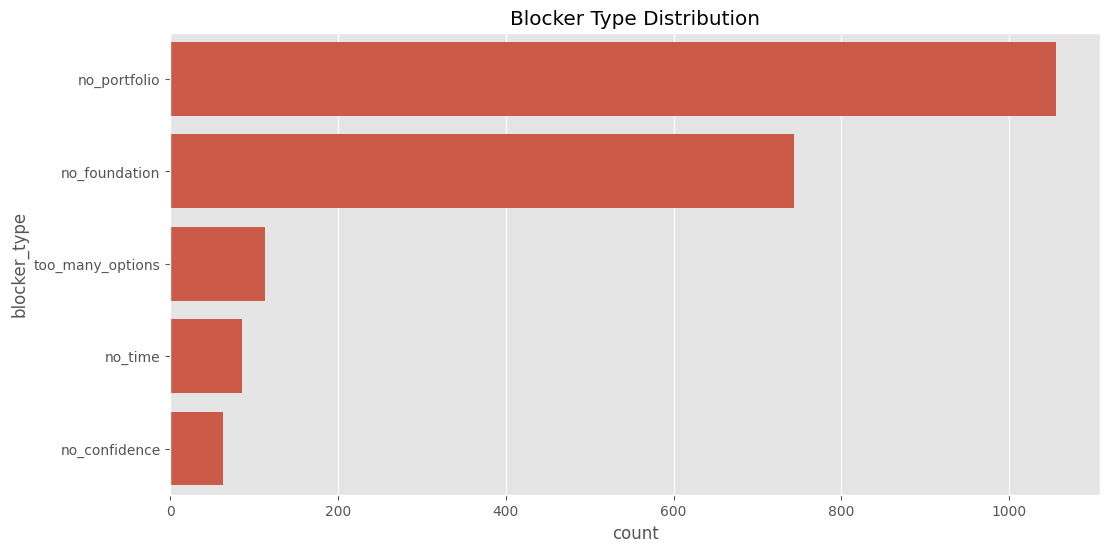

In [18]:
plt.figure(figsize=(12,6))

sns.countplot(
    data=df,
    y="blocker_type",
    order=df["blocker_type"].value_counts().index
)

plt.title("Blocker Type Distribution")

plt.show()